#  Global Energy Demand & Emissions Analysis

## What is this project about?
Energy powers everything — homes, factories, transport. But how we generate that energy 
determines how much we pollute.

This project analyzes energy data from 15 major countries between 2000 and 2023 to answer:
- Which countries consume the most energy?
- Does higher energy demand always mean higher pollution?
- Are countries actually getting cleaner over time?
- What factors drive greenhouse gas emissions the most?

## Dataset
Source: Our World in Data — Energy Dataset
Link: https://github.com/owid/energy-data
Contains: Energy consumption, renewable share, CO2 emissions, GDP, population for 
every country from 1900 to 2023.

## Step 1 — Loading the Data

We start by loading the raw dataset and checking its basic structure.
- How many rows and columns does it have?
- What columns are available?
- How much data is missing?

This is always the first step before doing anything with data.

In [1]:
import pandas as pd

df = pd.read_csv('owid-energy-data.csv')

print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())


(23377, 130)
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh

## Step 2 — Selecting Relevant Columns

The raw dataset has 130 columns — most of which we don't need.

We keep only 18 columns that are directly relevant to our analysis:
energy consumption by source, renewable share, emissions, GDP, and population.

We also remove continents and world aggregates (like "World", "Asia") 
because we want country-level analysis only.

Finally, we filter data from year 2000 onwards to focus on the modern energy era.

In [3]:
#select only relevant columns
columns_needed = [
    'country',
    'year',
    'population',
    'gdp',
    'energy_per_capita',
    'fossil_fuel_consumption',
    'renewables_consumption',
    'coal_consumption',
    'oil_consumption',
    'gas_consumption',
    'electricity_demand',
    'greenhouse_gas_emissions',
    'fossil_share_energy',
    'renewables_share_energy',
    'solar_share_energy',
    'wind_share_energy',
    'coal_share_energy',
    'low_carbon_share_energy'
] 

df = df[columns_needed]

# Remove rows where country is a region/continent, not an actual country
remove = ['World' , 'Asia', 'Europe', 'Africa', 'North America', 'South America', 'Oceania', 'Europian Union (27)']
df = df[~df['country'].isin(remove)]

# Filter years from 2000 onwards
df = df[df['year'] >= 2000]

# Check what we have now
print(df.shape)
print(df.isnull().sum())


    
    

(7459, 18)
country                        0
year                           0
population                  1790
gdp                         3669
energy_per_capita           2066
fossil_fuel_consumption     4859
renewables_consumption      4859
coal_consumption            4859
oil_consumption             4859
gas_consumption             4859
electricity_demand          1608
greenhouse_gas_emissions    1608
fossil_share_energy         4859
renewables_share_energy     4859
solar_share_energy          4859
wind_share_energy           4859
coal_share_energy           4859
low_carbon_share_energy     4859
dtype: int64


## Step 3 — Checking Data Quality by Country

Not every country reports data equally well. Some have complete records, 
others have many gaps.

Here we calculate what percentage of data is missing for each country.
Countries with less missing data are more reliable for analysis.
We use this to decide which 15 countries to focus on.

In [6]:
coverage = df.groupby('country').apply(
    lambda x: x.isnull().mean().mean()
).sort_values()

print(coverage.head(20))

country
Saudi Arabia            0.004444
Indonesia               0.004444
Trinidad and Tobago     0.004444
Turkmenistan            0.004444
Iraq                    0.004444
Venezuela               0.004444
United Arab Emirates    0.004444
Algeria                 0.004444
Hong Kong               0.004444
Iceland                 0.004444
Ukraine                 0.013333
Russia                  0.032051
Kuwait                  0.032051
Denmark                 0.032051
Peru                    0.032051
Czechia                 0.032051
Cyprus                  0.032051
Ireland                 0.032051
Romania                 0.032051
Philippines             0.032051
dtype: float64


C:\Users\Kanika Joshi\AppData\Local\Temp\ipykernel_19924\205812781.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = df.groupby('country').apply(


## Step 4 — Selecting 15 Countries

We pick 15 countries based on three criteria:
1. Good data coverage (low missing values)
2. Geographic diversity (countries from every region of the world)
3. Energy diversity (mix of fossil fuel heavy and renewable-heavy countries)

This ensures our analysis represents the whole world, not just one region.

In [2]:
countries = [
    'United States', 'China', 'India', 'Germany', 'Brazil', 'Russia', 'Saudi Arabia', 'Indonesia', 'France', 'Japan', 'Australia',
    'South Africa', 'Canada', 'Iraq', 'Ukraine'
]

df_filtered = df[df['country'].isin(countries)]

print(df_filtered.shape)
print(df_filtered['country'].value_counts())
print(df_filtered.isnull().sum())
      

(1796, 130)
country
Australia        126
Brazil           126
Canada           126
China            126
France           126
Germany          126
India            126
Japan            126
South Africa     126
United States    126
Indonesia        125
Iraq             125
Saudi Arabia     125
Ukraine          120
Russia            41
Name: count, dtype: int64
country                      0
year                         0
iso_code                     0
population                   0
gdp                        312
                          ... 
wind_elec_per_capita       927
wind_electricity           927
wind_energy_per_capita     936
wind_share_elec           1187
wind_share_energy          936
Length: 130, dtype: int64


## Step 5 — Handling Missing Values

Even after selecting the best countries, some data gaps remain.

We fill these gaps using "forward fill" — if a value is missing for a year, 
we use the previous year's value as the best estimate.

We do this separately for each country so Germany's data never fills 
into India's data by mistake.

After this step, we have a completely clean dataset ready for analysis.

In [10]:
df_filtered = df_filtered.groupby('country').apply(
    lambda x: x.ffill().bfill()
).reset_index(drop=True)

print(df_filtered.isnull().sum())

country                     0
year                        0
population                  0
gdp                         0
energy_per_capita           0
fossil_fuel_consumption     0
renewables_consumption      0
coal_consumption            0
oil_consumption             0
gas_consumption             0
electricity_demand          0
greenhouse_gas_emissions    0
fossil_share_energy         0
renewables_share_energy     0
solar_share_energy          0
wind_share_energy           0
coal_share_energy           0
low_carbon_share_energy     0
dtype: int64


C:\Users\Kanika Joshi\AppData\Local\Temp\ipykernel_19924\4223726416.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df_filtered.groupby('country').apply(


---
# Exploratory Data Analysis (EDA)

Now that our data is clean, we explore it visually to find patterns and insights.

EDA answers the "what is happening?" questions before we build any model.
Each chart below answers one specific question about global energy.

## Importing Visualization Libraries

We import two libraries for creating charts:
- **matplotlib** — the core plotting library in Python
- **seaborn** — built on top of matplotlib, makes charts look cleaner with less code

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

## Chart 1 — Who consumes the most electricity?

We plot electricity demand over time for all 15 countries.

China and USA dominate, so we split them into two separate charts 
for better readability.

**What to look for:** Which countries are growing fast? Which are flat or declining?

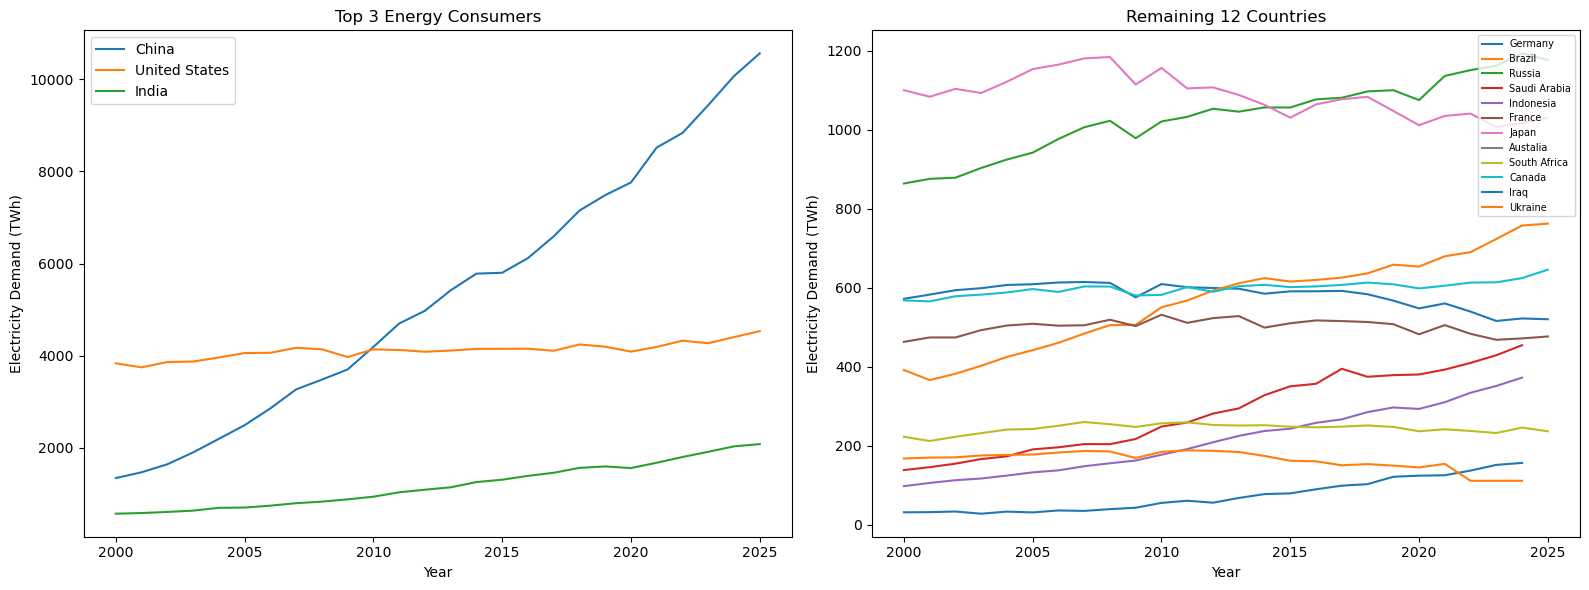

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Top 3 countries
top3 = ['China', 'United States', 'India']
for country in top3:
    data = df_filtered[df_filtered['country'] == country]
    ax1.plot(data['year'], data['electricity_demand'], label=country)
ax1.set_title('Top 3 Energy Consumers')
ax1.set_xlabel('Year')
ax1.set_ylabel('Electricity Demand (TWh)')
ax1.legend()

# Chart 2 - Remaining countries
rest = [c for c in countries if c not in top3]
for country in rest:
    data = df_filtered[df_filtered['country'] == country]
    ax2.plot(data['year'], data['electricity_demand'], label=country)
ax2.set_title('Remaining 12 Countries')
ax2.set_xlabel('Year')
ax2.set_ylabel('Electricity Demand (TWh)')
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Chart 2 — Does higher energy demand mean more pollution?

We compare electricity demand against greenhouse gas emissions for each country.

If the dots form an upward pattern (bottom-left to top-right), 
it means higher demand = higher emissions.

**What to look for:** Is the relationship consistent across all countries, 
or do some countries break the pattern?

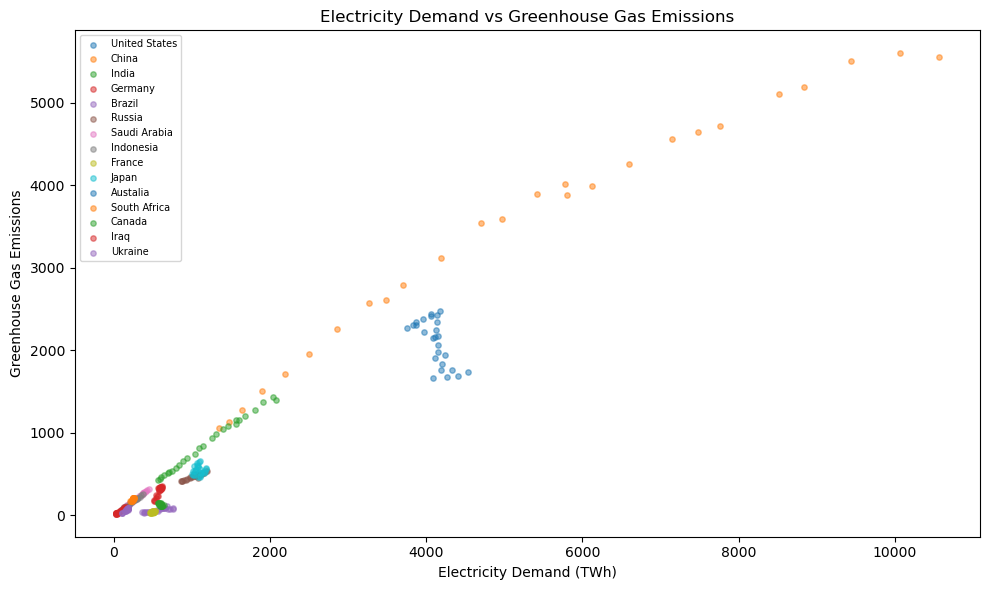

In [17]:
plt.figure(figsize =(10, 6))

for country in countries:
    data = df_filtered[df_filtered['country'] == country]
    plt.scatter(data['electricity_demand'],
                data['greenhouse_gas_emissions'],
                label= country, alpha=0.5, s=15)

plt.title('Electricity Demand vs Greenhouse Gas Emissions')
plt.xlabel('Electricity Demand (TWh)')
plt.ylabel('Greenhouse Gas Emissions')
plt.legend(fontsize = 7, loc = 'upper left')
plt.tight_layout()
plt.show()
           

## Chart 3 — Does using more renewables reduce pollution?

We compare renewable energy share against greenhouse gas emissions.

If renewables actually help, we should see high renewable share 
countries have low emissions.

**What to look for:** Countries that use a lot of renewables — 
do they actually emit less?

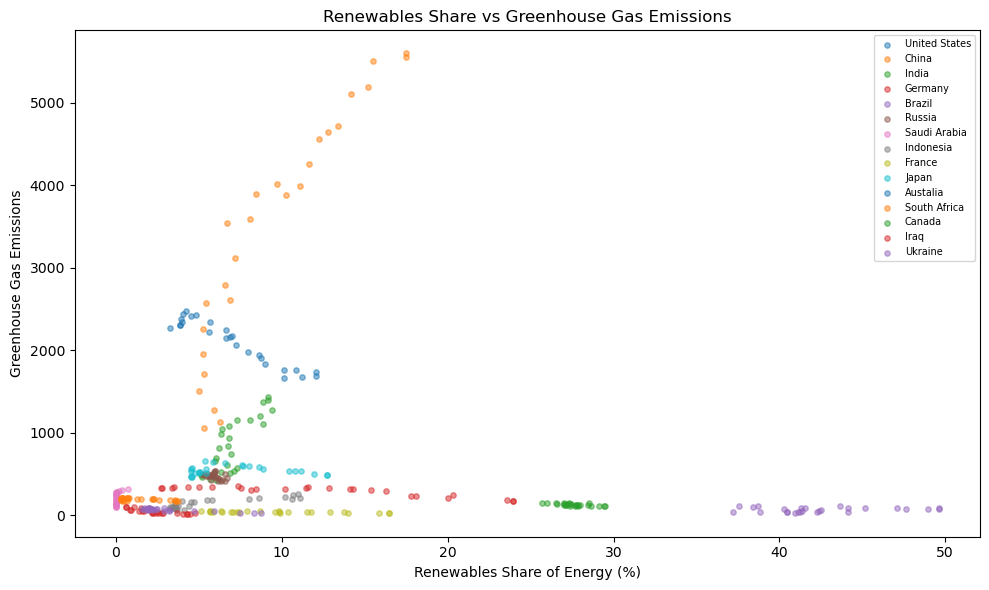

In [18]:
plt.figure(figsize=(10, 6))

for country in countries:
    data = df_filtered[df_filtered['country'] == country]
    plt.scatter(data['renewables_share_energy'],
                data['greenhouse_gas_emissions'],
                label=country, alpha=0.5, s=15)

plt.title('Renewables Share vs Greenhouse Gas Emissions')
plt.xlabel('Renewables Share of Energy (%)')
plt.ylabel('Greenhouse Gas Emissions')
plt.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

## Chart 4 — Which countries are getting cleaner over time?

This heatmap shows renewable energy share for each country across every year.

Color scale:
- Dark green = high renewable share (clean energy)
- Dark red = low renewable share (fossil fuel dependent)

**What to look for:** Are colors shifting from red to green over time? 
How fast is the transition happening?

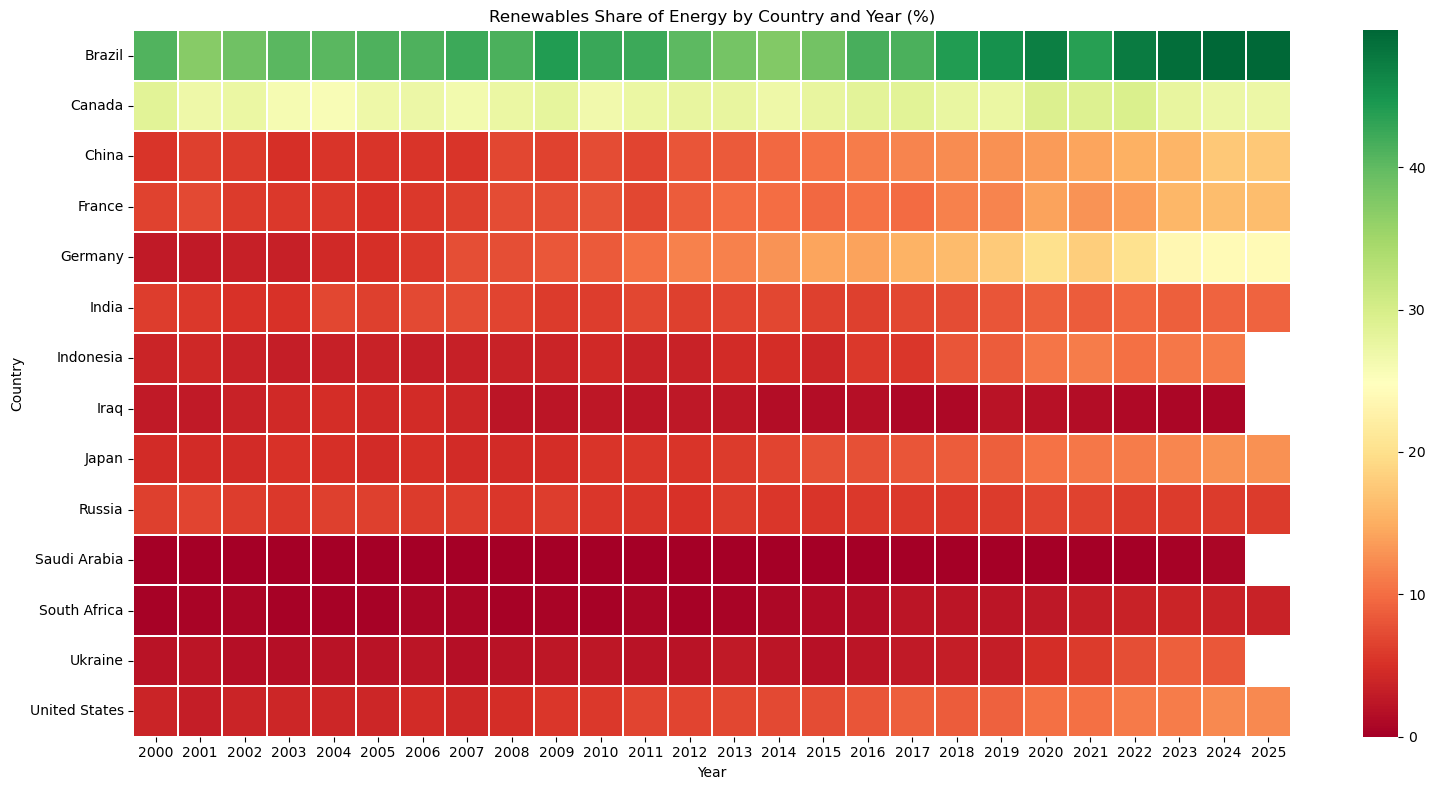

In [19]:
pivot = df_filtered.pivot_table(
    index='country', 
    columns='year', 
    values='renewables_share_energy'
)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='RdYlGn', linewidths=0.3, annot=False)
plt.title('Renewables Share of Energy by Country and Year (%)')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## Chart 5 — How have emissions changed between 2000 and 2023?

We directly compare greenhouse gas emissions per country in 2000 vs 2023.

Blue bar = emissions in 2000
Orange bar = emissions in 2023

**What to look for:** Which countries increased emissions? 
Which countries actually reduced them?

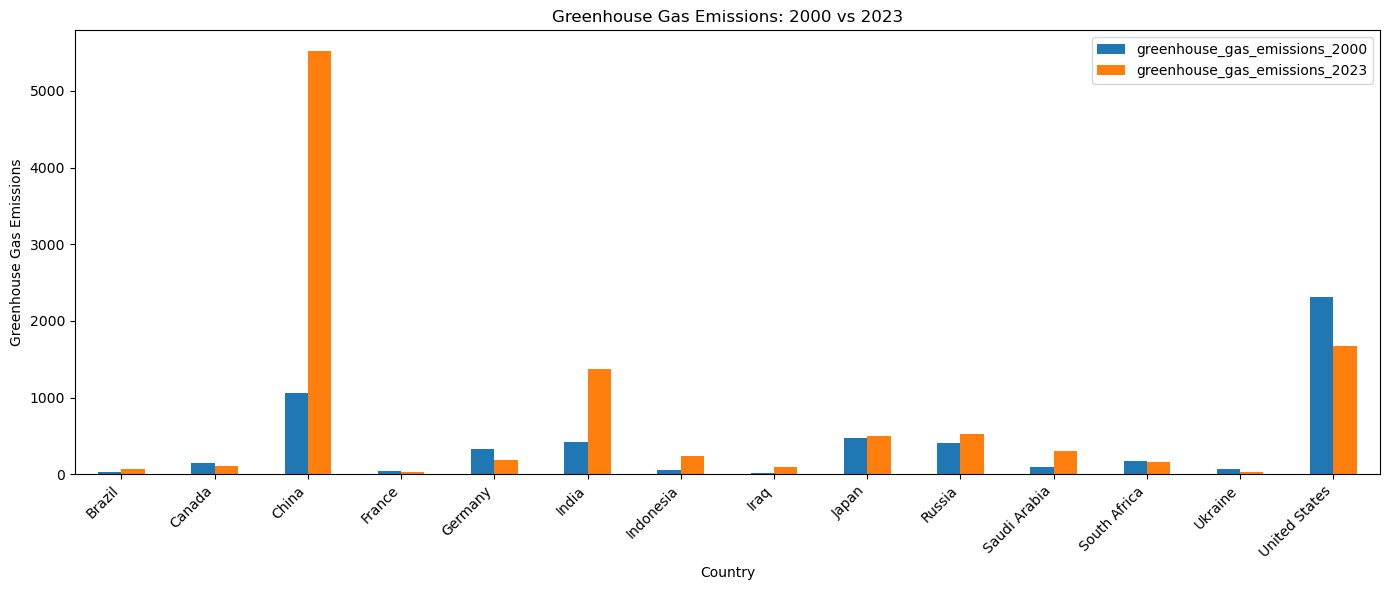

In [20]:
df_2000 = df_filtered[df_filtered['year'] == 2000][['country', 'greenhouse_gas_emissions']].set_index('country')
df_2023 = df_filtered[df_filtered['year'] == 2023][['country', 'greenhouse_gas_emissions']].set_index('country')

comparison = df_2000.join(df_2023, lsuffix='_2000', rsuffix='_2023')

comparison.plot(kind='bar', figsize=(14, 6))
plt.title('Greenhouse Gas Emissions: 2000 vs 2023')
plt.xlabel('Country')
plt.ylabel('Greenhouse Gas Emissions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Machine Learning — Predicting Greenhouse Gas Emissions

Now we move from "what happened" to "why did it happen".

We build a machine learning model that predicts greenhouse gas emissions 
based on how a country generates its energy.

**Problem type:** Regression (predicting a number, not a category)

**Input features:** fossil fuel consumption, renewables consumption, 
coal, oil, gas consumption, electricity demand, GDP, population

**Target variable:** Greenhouse gas emissions

**Models we'll compare:**
- Linear Regression — simplest baseline model
- Random Forest — more powerful, handles complex patterns
- XGBoost — advanced model, usually highest performance

## Step 6 — Preparing Data for Machine Learning

We separate our data into:
- Features (X) — the inputs the model uses to make predictions
- Target (y) — what we want the model to predict (emissions)

Then we split into:
- Training set (80%) — data the model learns from
- Test set (20%) — data we hide from the model to test how well it learned

If the model predicts the hidden test data accurately, 
it has genuinely learned the pattern.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features and target
features = [
    'fossil_fuel_consumption',
    'renewables_consumption',
    'coal_consumption',
    'oil_consumption',
    'gas_consumption',
    'electricity_demand',
    'fossil_share_energy',
    'renewables_share_energy',
    'population',
    'gdp'
]

target = 'greenhouse_gas_emissions'

X = df_filtered[features]
y = df_filtered[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (288, 10)
Test size: (72, 10)


## Step 7 — Training and Evaluating 3 Models

We train all three models and measure their performance using:

- **MAE (Mean Absolute Error)** — on average, how many units off are predictions
- **RMSE (Root Mean Squared Error)** — similar to MAE but punishes bigger mistakes more
- **R² Score** — how much of the variation the model explains. 1.0 = perfect, 0 = useless

Lower MAE and RMSE = better. Higher R² = better.

In [24]:
# Train all 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")

Linear Regression: MAE=41.58, RMSE=68.51, R2=0.9973
Random Forest: MAE=35.74, RMSE=77.89, R2=0.9965
XGBoost: MAE=49.63, RMSE=121.82, R2=0.9913


## Step 8 — Which factors drive emissions the most?

Using the Random Forest model, we extract "feature importance" — 
a score showing how much each input variable contributed to the predictions.

Higher importance = that factor has more influence on emissions.

This tells us: if a country wants to reduce emissions, 
which energy factor should they change first?

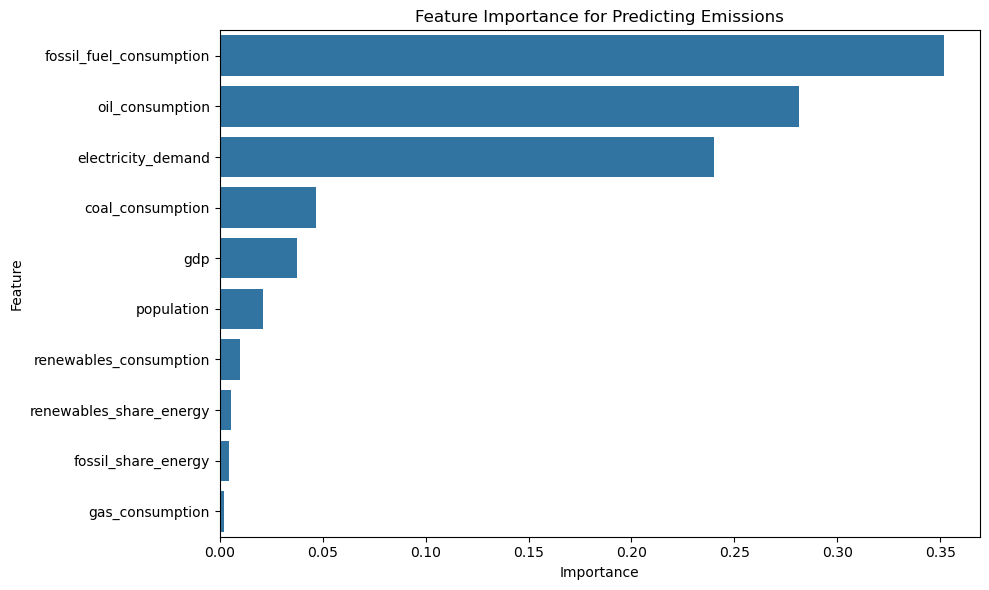

In [25]:
# Feature importance from Random Forest
importances = models['Random Forest'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Predicting Emissions')
plt.tight_layout()
plt.show()

In [26]:
df_filtered.to_csv('clean_energy_data.csv', index=False)

## Step 9 — Saving the Clean Dataset

We save the cleaned and filtered dataset as a CSV file.
This file is used by our Streamlit dashboard to display 
interactive charts without rerunning the entire notebook.

---
# Key Findings & Conclusion

After analyzing 23 years of energy data across 15 major countries, here is what we found:

### Finding 1 — China is the biggest challenge
China's electricity demand grew nearly 7x from 2000 to 2023. 
Its emissions grew 5x in the same period. No other country comes close to this scale.

### Finding 2 — High demand does not always mean high emissions
USA uses more electricity than most countries but reduced emissions from 2000 to 2023.
The reason: gradual shift away from coal toward gas and renewables.

### Finding 3 — Clean energy mix is the real solution
Brazil and France have high energy demand but near-zero emissions.
Brazil runs on hydropower. France runs on nuclear.
This proves that HOW you generate energy matters more than HOW MUCH you use.

### Finding 4 — Most of the world is still fossil fuel dependent
Despite 25 years of climate policy, most countries in our analysis 
are still 80%+ fossil fuel dependent. The transition is happening too slowly.

### Finding 5 — Fossil fuel consumption is the strongest predictor of emissions
Our machine learning model confirms: fossil fuel and oil consumption 
are by far the biggest drivers of greenhouse gas emissions.
Renewable share alone has surprisingly little predictive power.

### Model Performance
| Model | MAE | RMSE | R² |
|-------|-----|------|----|
| Linear Regression | 41.58 | 68.51 | 0.9973 |
| Random Forest | 35.74 | 77.89 | 0.9965 |
| XGBoost | 49.63 | 121.82 | 0.9913 |

All three models explain 99%+ of variation in emissions. 
Best overall model: Linear Regression.

### Business Applications
- Energy policy teams can use this to identify which countries need most urgent intervention
- Climate consultancies can estimate emission impact of switching energy sources
- ESG investors can assess climate risk in country portfolios